In [ ]:
import os, sys

# Make sure this notebook works regardless of Jupyter's starting directory:
# CSV paths and the `data_loaders`/`config`/`model` imports below all assume
# the current working directory is the project root (one level up from
# notebooks/).
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), os.pardir))
os.chdir(PROJECT_ROOT)
sys.path.append(PROJECT_ROOT)
print("Project root:", PROJECT_ROOT)


In [1]:
# Cell 1: core imports
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tensorflow.keras.optimizers.legacy import Adam
from sklearn.metrics import mean_absolute_error
import os

# Swap the loader below to try a different sentiment aggregation/windowing
# variant (see data_loaders/README.md for what each one does):
# from data_loaders.daily_avg_windowed import get_datasets
# from data_loaders.daily_sum import get_datasets
# from data_loaders.daily_sum_windowed import get_datasets
# from data_loaders.article_level import get_datasets
# from data_loaders.article_level_windowed import get_datasets
from data_loaders.daily_avg import get_datasets
from model import (build_price, build_ft, 
                   tune_price_model, tune_finetune_model,
                   build_best_price_model, build_best_ft_model,
                   get_callbacks)
from config import cfg

/Users/parthdesai/.virtualenvs/r-tensorflow/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [2]:
# ─── New CSV helpers ─────────────────────────────────────────────────────────
def setup_metric_csv(csv_path: str, initial_rows: list):
    if not os.path.isfile(csv_path):
        df = pd.DataFrame(index=initial_rows, columns=[])
        df.index.name = 'Metric'
        df.to_csv(csv_path)
        print(f"Initialized {csv_path} with rows {initial_rows}")

def upsert_experiment(csv_path: str,
                      exp_name: str,
                      row_values: dict,
                      overwrite: bool = False):
    df = pd.read_csv(csv_path, index_col='Metric')

    # ensure the column exists
    if exp_name not in df.columns:
        df[exp_name] = np.nan

    # ensure every metric is a row
    for metric in row_values:
        if metric not in df.index:
            df.loc[metric] = np.nan

    # now write or only fill blanks
    for metric, value in row_values.items():
        current = df.at[metric, exp_name]
        if pd.isna(current) or overwrite:
            df.at[metric, exp_name] = value
        else:
            # skip because there's already a value and overwrite=False
            print(f"→ skipping {metric} (already has {current:.3f})")

    df.to_csv(csv_path)
    print(f"Upserted experiment '{exp_name}' (overwrite={overwrite})")


In [3]:
# ─── Config ─────────────────────────────────────────────────────────────────
CSV_FILE = 'results/comparison.csv'
OUTPUT_DIR = 'results/comparison_output'

# seed exactly the rows you want
setup_metric_csv(CSV_FILE, initial_rows=[
    'Price-only','Kalshi','SPY','Mag7','Tariffs',
    'KalshiInput','AllExcKalshi','All'
])

EXP_NAME   = 'Article Sent'   # this becomes your new column name

# make sure your folder exists
os.makedirs(OUTPUT_DIR, exist_ok=True)

## SPY Sentiment Only

→ get_datasets: start
→ get_datasets: loading SPY
  → load_spy()
   SPY post-train shape: (1251, 1)
→ joining daily sentiment
  → load_sentiment()
→ get_datasets: loading raw Kalshi for baseline
  → load_kalshi() (optimized)
→ get_datasets: loading raw Kalshi for baseline
  → load_kalshi() (optimized)
→ scaling features
→ making sequences
→ splitting pretrain/fine-tune
→ creating tf.data datasets
→ preparing test data
→ get_datasets: done
=== Training Price-Only Model ===
Tuning price-only model hyperparameters...
Reloading Tuner from tuner_results/price_model_tuning/tuner0.json
Best price model hyperparameters:
  lstm_units: 112
  dropout_rate: 0.4
  l2_reg: 1e-06
  learning_rate: 0.005
Epoch 1/40
→ scaling features
→ making sequences
→ splitting pretrain/fine-tune
→ creating tf.data datasets
→ preparing test data
→ get_datasets: done
=== Training Price-Only Model ===
Tuning price-only model hyperparameters...
Reloading Tuner from tuner_results/price_model_tuning/tuner0.json
Best pric

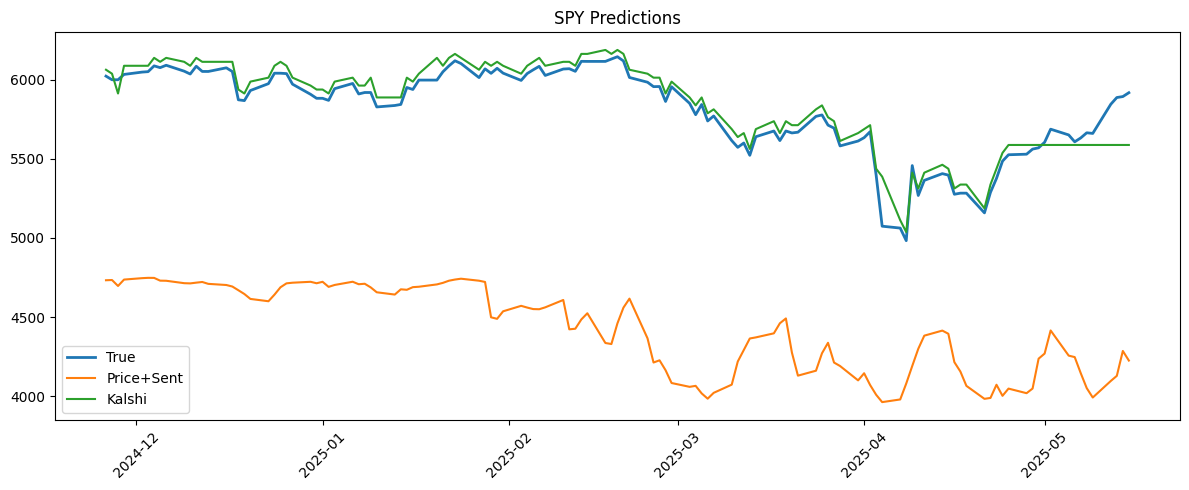

In [6]:
MODEL_NAME = 'SPY'

# Import the new tuning functions
from model import (build_price, build_ft, 
                   tune_price_model, tune_finetune_model,
                   build_best_price_model, build_best_ft_model,
                   get_callbacks)

(ds_pre_tr_spy,
    ds_pre_val_spy,
    ds_ft_spy,          
    ds_val_spy,         
    Xp_test,
    Xs_test,
    y_true,
    test_dates,
    price_scaler,
    kalshi_df,
    X_pre_tr_spy,   # <-- 11th
    y_pre_tr_spy,   # <-- 12th
    X_pre_val_spy,  # <-- 13th
    y_pre_val_spy   # <-- 14th
) = get_datasets(
    cfg,
    use_sentiment=True,
    use_mag=False,
    use_tariff=False,
    use_kalshi=False
)


# Convert datasets to numpy arrays for tuning (if needed)
def dataset_to_arrays(dataset):
    """Convert tf.data.Dataset to numpy arrays for tuning"""
    X_list = []
    y_list = []
    for batch in dataset:
        if isinstance(batch[0], (list, tuple)):
            # Multiple inputs (fine-tune model)
            X_batch = [x.numpy() for x in batch[0]]
            if len(X_list) == 0:
                X_list = [[] for _ in X_batch]
            for i, x in enumerate(X_batch):
                X_list[i].append(x)
        else:
            # Single input (price-only model)
            X_list.append(batch[0].numpy())
        y_list.append(batch[1].numpy())
    
    if isinstance(X_list[0], list):
        # Multiple inputs
        return [np.vstack(x_arrays) for x_arrays in X_list], np.vstack(y_list)
    else:
        # Single input
        return np.vstack(X_list), np.vstack(y_list)

# 2) TRAIN price-only model
print("=== Training Price-Only Model ===")

if cfg.get("use_tuning", False):
    print("Tuning price-only model hyperparameters...")
    # FIXED: Use the numpy arrays returned directly from get_datasets
    # instead of converting from tf.data.Dataset
    
    # Tune hyperparameters
    best_hps_price, tuner_price = tune_price_model(
        X_pre_tr_np_spy, y_pre_tr_np_spy, 
        X_pre_val_np_spy, y_pre_val_np_spy,
        max_trials=cfg["tuning_max_trials"],
        executions_per_trial=cfg["tuning_executions"]
    )
    
    print("Best price model hyperparameters:")
    for param in ['lstm_units', 'dropout_rate', 'l2_reg', 'learning_rate']:
        print(f"  {param}: {best_hps_price.get(param)}")
    
    # Build best model
    price_model_spy = build_best_price_model(best_hps_price)
    price_model_spy.compile(
        Adam(best_hps_price.get('learning_rate')), 
        loss="mse"
    )
else:
    print("Using default hyperparameters for price model...")
    price_model_spy = build_price()
    price_model_spy.compile(Adam(cfg["lr_pre"]), loss="mse")

# Train with early stopping
price_history = price_model_spy.fit(
    ds_pre_tr_spy, 
    validation_data=ds_pre_val_spy,
    epochs=cfg["pre_epochs"],
    callbacks=get_callbacks(patience=cfg.get("patience", 10)),
    verbose=1
)

# 3) TRAIN price+sentiment model
print("\n=== Training Price+Sentiment Model ===")

if Xs_test_spy is not None:
    s_dims = Xs_test_spy.shape[2]
    
    if cfg.get("use_tuning", False):
        print("Tuning fine-tune model hyperparameters...")
        # Convert dataset to arrays for tuning
        X_ft_tr, y_ft_tr = dataset_to_arrays(ds_ft_spy)
        X_ft_val, y_ft_val = dataset_to_arrays(ds_val_spy)
        
        # Tune hyperparameters
        best_hps_ft, tuner_ft = tune_finetune_model(
            X_ft_tr, y_ft_tr, X_ft_val, y_ft_val, s_dims,
            max_trials=cfg["tuning_max_trials"],
            executions_per_trial=cfg["tuning_executions"]
        )
        
        print("Best fine-tune model hyperparameters:")
        for param in ['price_lstm_units', 'aux_lstm_units', 'dense_units', 'dropout_rate', 'l2_reg', 'learning_rate']:
            print(f"  {param}: {best_hps_ft.get(param)}")
        
        # Build best model
        ft_model_spy = build_best_ft_model(s_dims, best_hps_ft)
        learning_rate = best_hps_ft.get('learning_rate')
    else:
        print("Using default hyperparameters for fine-tune model...")
        ft_model_spy = build_ft(s_dims)
        learning_rate = cfg["lr_ft"]
    
    # Transfer weights from price model (if architectures are compatible)
    try:
        ft_model_spy.get_layer("ps").set_weights(
            price_model_spy.get_layer("ps").get_weights()
        )
        print("Successfully transferred weights from price model")
    except Exception as e:
        print(f"Could not transfer weights (architecture mismatch): {e}")
        print("Training from scratch...")
    
    # Phase 1: Frozen price layer
    ft_model_spy.get_layer("ps").trainable = False
    ft_model_spy.compile(Adam(learning_rate), loss="mse")
    
    print("Phase 1: Training with frozen price layer...")
    ft_history_1 = ft_model_spy.fit(
        ds_ft_spy, 
        validation_data=ds_val_spy,
        epochs=cfg["ft_epochs"]//2,
        callbacks=get_callbacks(patience=cfg.get("patience", 10)),
        verbose=1
    )
    
    # Phase 2: Unfreeze all layers
    ft_model_spy.get_layer("ps").trainable = True
    ft_model_spy.compile(Adam(learning_rate), loss="mse")
    
    print("Phase 2: Training with all layers unfrozen...")
    ft_history_2 = ft_model_spy.fit(
        ds_ft_spy, 
        validation_data=ds_val_spy,
        epochs=cfg["ft_epochs"]//2,
        callbacks=get_callbacks(patience=cfg.get("patience", 10)),
        verbose=1
    )
else:
    ft_model_spy = None
    print("No sentiment data available, skipping fine-tune model")

# 4) EVALUATE
print("\n=== Evaluation ===")

y_ps_spy = np.exp(
    price_scaler_spy.inverse_transform(
        price_model_spy.predict(Xp_test_spy).reshape(-1,1)
    )
).flatten()

if ft_model_spy is not None:
    y_p_spy = np.exp(
        price_scaler_spy.inverse_transform(
            ft_model_spy.predict([Xp_test_spy, Xs_test_spy]).reshape(-1,1)
        )
    ).flatten()
else:
    y_p_spy = None

# compute MAEs
mae_price_spy = mean_absolute_error(y_true_spy, y_ps_spy)
print("Price-only MAE:", mae_price_spy)

if ft_model_spy is not None:
    mae_sent_spy = mean_absolute_error(y_true_spy, y_p_spy)
    print("Price+Sent MAE:", mae_sent_spy)
else:
    mae_sent_spy = np.nan

# ─── Kalshi baseline (aligned) ───────────────────────────────────────────────
if kalshi_df_spy is not None:
    kalshi_raw = kalshi_df_spy["kalshi_price"]
    # align to exact test dates, forward-filling missing entries
    kalshi_aligned = kalshi_raw.reindex(test_dates_spy, method="ffill")
    # sanity check: lengths match
    assert len(kalshi_aligned) == len(y_true_spy)
    mae_kalshi = mean_absolute_error(y_true_spy, kalshi_aligned.values)
    print("Kalshi MAE (aligned):", mae_kalshi)
else:
    mae_kalshi = np.nan

# Print hyperparameter tuning summary
if cfg.get("use_tuning", False):
    print("\n=== Hyperparameter Tuning Summary ===")
    if 'best_hps_price' in locals():
        print("Price model - Best trial achieved val_loss:", 
              tuner_price.oracle.get_best_trials(1)[0].score)
    if 'best_hps_ft' in locals():
        print("Fine-tune model - Best trial achieved val_loss:", 
              tuner_ft.oracle.get_best_trials(1)[0].score)

# 5) WRITE TO CSV (rows=metrics/models, columns=experiments)
upsert_experiment(
    CSV_FILE,
    exp_name   = EXP_NAME,
    row_values = {
        'Price-only': mae_price_spy,
        'Kalshi':     mae_kalshi,
        'SPY':        mae_sent_spy
    },
    overwrite= True
)

# 6) PLOT & SAVE
fig_spy, ax_spy = plt.subplots(figsize=(12,5))
ax_spy.plot(test_dates_spy, y_true_spy,      label="True",        lw=2)
if ft_model_spy is not None:
    ax_spy.plot(test_dates_spy, y_p_spy,     label="Price+Sent")
if kalshi_df_spy is not None:
    ax_spy.plot(test_dates_spy, kalshi_aligned, label="Kalshi")
ax_spy.set_title(f"{MODEL_NAME} Predictions")
ax_spy.legend()
plt.xticks(rotation=45)
plt.tight_layout()

fig_spy.savefig(os.path.join(OUTPUT_DIR, f"{MODEL_NAME}.png"), bbox_inches='tight')
print(f"Saved plot to {os.path.join(OUTPUT_DIR, MODEL_NAME + '.png')}")

# Optional: Save tuning results
if cfg.get("use_tuning", False):
    try:
        if 'tuner_price' in locals():
            tuner_price.results_summary()
        if 'tuner_ft' in locals():
            tuner_ft.results_summary()
    except Exception as e:
        print(f"Could not display tuning summary: {e}")

## Mag 7

→ get_datasets: start
→ get_datasets: loading SPY
  → load_spy()
   SPY post-train shape: (1251, 1)
→ joining Mag-7 sentiment
  → load_mag()
→ get_datasets: loading raw Kalshi for baseline
  → load_kalshi() (optimized)


→ scaling features
→ making sequences
→ splitting pretrain/fine-tune
→ creating tf.data datasets
→ preparing test data
→ get_datasets: done
Epoch 1/40
69/69 - 1s - loss: 0.0668 - val_loss: 0.0339 - 1s/epoch - 20ms/step
Epoch 2/40
69/69 - 0s - loss: 0.0172 - val_loss: 0.0305 - 398ms/epoch - 6ms/step
Epoch 3/40
69/69 - 0s - loss: 0.0159 - val_loss: 0.0325 - 462ms/epoch - 7ms/step
Epoch 4/40
69/69 - 0s - loss: 0.0149 - val_loss: 0.0294 - 498ms/epoch - 7ms/step
Epoch 5/40
69/69 - 0s - loss: 0.0139 - val_loss: 0.0249 - 391ms/epoch - 6ms/step
Epoch 6/40
69/69 - 0s - loss: 0.0129 - val_loss: 0.0239 - 408ms/epoch - 6ms/step
Epoch 7/40
69/69 - 0s - loss: 0.0124 - val_loss: 0.0238 - 367ms/epoch - 5ms/step
Epoch 8/40
69/69 - 0s - loss: 0.0117 - val_loss: 0.0213 - 395ms/epoch - 6ms/step
Epoch 9/40
69/69 - 0s - loss: 0.0115 - val_loss: 0.0206 - 378ms/epoch - 5ms/step
Epoch 10/40
69/69 - 0s - loss: 0.0114 - val_loss: 0.0209 - 490ms/epoch - 7ms/step
Epoch 11/40
69/69 - 0s - loss: 0.0109 - val_loss: 0

Epoch 1/20
69/69 [==============================] - 2s 9ms/step - loss: 0.5588 - val_loss: 1.9995
Epoch 2/20
69/69 [==============================] - 0s 4ms/step - loss: 0.3346 - val_loss: 1.6994
Epoch 3/20
69/69 [==============================] - 0s 4ms/step - loss: 0.2887 - val_loss: 1.3967
Epoch 4/20
69/69 [==============================] - 0s 4ms/step - loss: 0.2285 - val_loss: 0.9961
Epoch 5/20
69/69 [==============================] - 0s 4ms/step - loss: 0.2294 - val_loss: 0.7714
Epoch 6/20
69/69 [==============================] - 0s 4ms/step - loss: 0.2088 - val_loss: 0.3938
Epoch 7/20
69/69 [==============================] - 0s 4ms/step - loss: 0.1907 - val_loss: 0.2993
Epoch 8/20
69/69 [==============================] - 0s 4ms/step - loss: 0.1896 - val_loss: 0.1719
Epoch 9/20
69/69 [==============================] - 0s 4ms/step - loss: 0.1932 - val_loss: 0.1296
Epoch 10/20
69/69 [==============================] - 0s 4ms/step - loss: 0.1884 - val_loss: 0.0939
Epoch 11/20
69/69 [

Epoch 1/20
69/69 [==============================] - 2s 10ms/step - loss: 0.1602 - val_loss: 0.0287
Epoch 2/20
69/69 [==============================] - 0s 6ms/step - loss: 0.1311 - val_loss: 0.0400
Epoch 3/20
69/69 [==============================] - 0s 6ms/step - loss: 0.1265 - val_loss: 0.0369
Epoch 4/20
69/69 [==============================] - 0s 6ms/step - loss: 0.1356 - val_loss: 0.0372
Epoch 5/20
69/69 [==============================] - 0s 6ms/step - loss: 0.1189 - val_loss: 0.0363
Epoch 6/20
69/69 [==============================] - 0s 6ms/step - loss: 0.1212 - val_loss: 0.0303
Epoch 7/20
69/69 [==============================] - 0s 7ms/step - loss: 0.1231 - val_loss: 0.0343
Epoch 8/20
69/69 [==============================] - 0s 6ms/step - loss: 0.1144 - val_loss: 0.0232
Epoch 9/20
69/69 [==============================] - 0s 5ms/step - loss: 0.1097 - val_loss: 0.0236
Epoch 10/20
69/69 [==============================] - 0s 5ms/step - loss: 0.1170 - val_loss: 0.0270
Epoch 11/20
69/69 

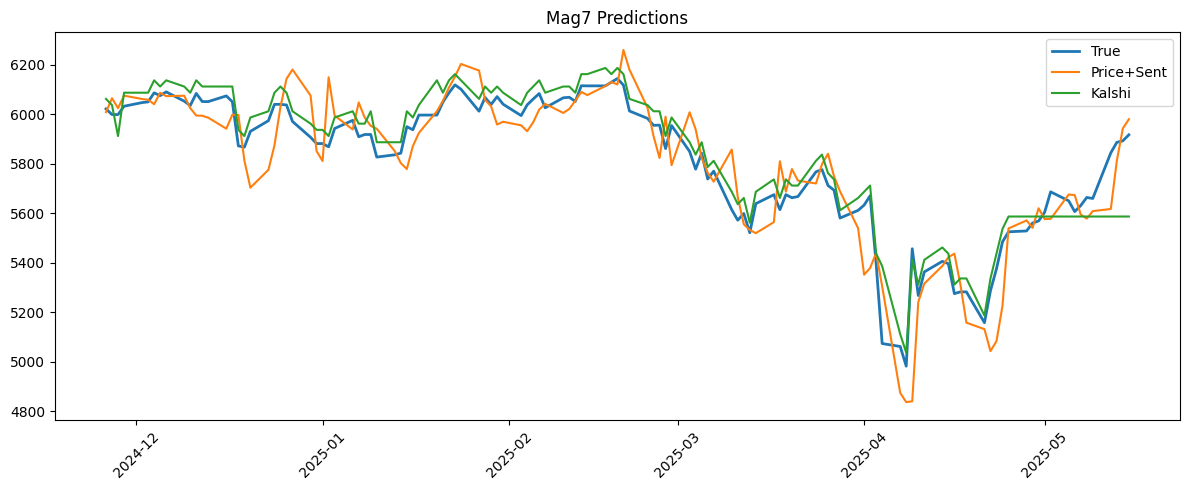

In [9]:
MODEL_NAME = 'Mag7'          # for plot filename

# 1) LOAD (Mag-7 sentiment on, everything else off)
ds_pre_tr_mag7, ds_pre_val_mag7, \
ds_ft_mag7,    ds_val_mag7, \
Xp_test_mag7,  Xs_test_mag7, \
y_true_mag7,   test_dates_mag7, \
price_scaler_mag7, kalshi_df_mag7 = get_datasets(
    cfg,
    use_sentiment=False,
    use_mag=True,
    use_tariff=False,
    use_kalshi=False
)

# 2) TRAIN price-only
price_model_mag7 = build_price()
price_model_mag7.compile(Adam(cfg["lr_pre"]), loss="mse")
price_model_mag7.fit(
    ds_pre_tr_mag7, validation_data=ds_pre_val_mag7,
    epochs=cfg["pre_epochs"], verbose=2
)

# 3) TRAIN price+all-sentiment (fine-tune)
ft_model_mag7 = build_ft(Xs_test_mag7.shape[2])
ft_model_mag7.get_layer("ps")\
    .set_weights(price_model_mag7.get_layer("ps").get_weights())
ft_model_mag7.get_layer("ps").trainable = False
ft_model_mag7.compile(Adam(cfg["lr_ft"]), loss="mse")
ft_model_mag7.fit(
    ds_ft_mag7, validation_data=ds_val_mag7,
    epochs=cfg["ft_epochs"]//2, verbose=1
)
ft_model_mag7.get_layer("ps").trainable = True
ft_model_mag7.compile(Adam(cfg["lr_ft"]), loss="mse")
ft_model_mag7.fit(
    ds_ft_mag7, validation_data=ds_val_mag7,
    epochs=cfg["ft_epochs"]//2, verbose=1
)

# 4) EVALUATE
y_ps_mag7 = np.exp(
    price_scaler_mag7.inverse_transform(
        price_model_mag7.predict(Xp_test_mag7).reshape(-1,1)
    )
).flatten()

y_pa_mag7 = np.exp(
    price_scaler_mag7.inverse_transform(
        ft_model_mag7.predict([Xp_test_mag7, Xs_test_mag7]).reshape(-1,1)
    )
).flatten()

# compute MAEs
mae_price_mag7   = mean_absolute_error(y_true_mag7, y_ps_mag7)
mae_allsent_mag7 = mean_absolute_error(y_true_mag7, y_pa_mag7)
print("Mag7 Price-only MAE:", mae_price_mag7)
print("Mag7 Price+Sent MAE:", mae_allsent_mag7)

# ─── Kalshi baseline (aligned) ───────────────────────────────────────────────
if kalshi_df_mag7 is not None:
    # grab raw Kalshi series
    kalshi_raw_mag7 = kalshi_df_mag7["kalshi_price"]
    # reindex to test dates with forward-fill
    kalshi_aligned_mag7 = kalshi_raw_mag7.reindex(test_dates_mag7, method="ffill")
    # ensure lengths match
    assert len(kalshi_aligned_mag7) == len(y_true_mag7)
    mae_kalshi_mag7 = mean_absolute_error(y_true_mag7, kalshi_aligned_mag7.values)
    print("Mag7 Kalshi MAE (aligned):", mae_kalshi_mag7)
else:
    mae_kalshi_mag7 = np.nan

# 5) WRITE TO CSV
upsert_experiment(
    CSV_FILE,
    exp_name   = EXP_NAME,
    row_values = {
        'Price-only': mae_price_mag7,
        'Kalshi':     mae_kalshi_mag7,
        'Mag7':       mae_allsent_mag7
    },
    overwrite= True
)

# 6) PLOT & SAVE
fig_mag7, ax_mag7 = plt.subplots(figsize=(12,5))
ax_mag7.plot(test_dates_mag7, y_true_mag7,           label="True",        lw=2)
ax_mag7.plot(test_dates_mag7, y_pa_mag7,             label="Price+Sent")
if kalshi_df_mag7 is not None:
    ax_mag7.plot(test_dates_mag7, kalshi_aligned_mag7, label="Kalshi")
ax_mag7.set_title(f"{MODEL_NAME} Predictions")
ax_mag7.legend()
plt.xticks(rotation=45)
plt.tight_layout()

fig_mag7.savefig(os.path.join(OUTPUT_DIR, f"{MODEL_NAME}.png"), bbox_inches='tight')
print(f"Saved plot to {os.path.join(OUTPUT_DIR, MODEL_NAME + '.png')}")


## Tariffs

In [ ]:
MODEL_NAME = 'Tariffs'

# 1) LOAD (Tariff sentiment on, everything else off)
ds_pre_tr_tariffs, ds_pre_val_tariffs, \
ds_ft_tariffs,    ds_val_tariffs, \
Xp_test_tariffs,  Xs_test_tariffs, \
y_true_tariffs,   test_dates_tariffs, \
price_scaler_tariffs, kalshi_df_tariffs = get_datasets(
    cfg,
    use_sentiment=False,
    use_mag=False,
    use_tariff=True,
    use_kalshi=False
)

# 2) TRAIN price-only
price_model_tariffs = build_price()
price_model_tariffs.compile(Adam(cfg["lr_pre"]), loss="mse")
price_model_tariffs.fit(
    ds_pre_tr_tariffs, validation_data=ds_pre_val_tariffs,
    epochs=cfg["pre_epochs"], verbose=2
)

# 3) TRAIN price+tariff-sentiment (fine-tune)
ft_model_tariffs = build_ft(Xs_test_tariffs.shape[2])
ft_model_tariffs.get_layer("ps")\
    .set_weights(price_model_tariffs.get_layer("ps").get_weights())
ft_model_tariffs.get_layer("ps").trainable = False
ft_model_tariffs.compile(Adam(cfg["lr_ft"]), loss="mse")
ft_model_tariffs.fit(
    ds_ft_tariffs, validation_data=ds_val_tariffs,
    epochs=cfg["ft_epochs"]//2, verbose=1
)
ft_model_tariffs.get_layer("ps").trainable = True
ft_model_tariffs.compile(Adam(cfg["lr_ft"]), loss="mse")
ft_model_tariffs.fit(
    ds_ft_tariffs, validation_data=ds_val_tariffs,
    epochs=cfg["ft_epochs"]//2, verbose=1
)

# 4) EVALUATE
y_ps_tariffs = np.exp(
    price_scaler_tariffs.inverse_transform(
        price_model_tariffs.predict(Xp_test_tariffs).reshape(-1,1)
    )
).flatten()
y_pa_tariffs = np.exp(
    price_scaler_tariffs.inverse_transform(
        ft_model_tariffs.predict([Xp_test_tariffs, Xs_test_tariffs]).reshape(-1,1)
    )
).flatten()

# compute MAEs
mae_price_tariffs  = mean_absolute_error(y_true_tariffs, y_ps_tariffs)
mae_sent_tariffs   = mean_absolute_error(y_true_tariffs, y_pa_tariffs)
print("Tariffs Price-only MAE:", mae_price_tariffs)
print("Tariffs Price+Sent MAE:", mae_sent_tariffs)

# ─── Kalshi baseline (aligned) ───────────────────────────────────────────────
if kalshi_df_tariffs is not None:
    # take the raw Kalshi series
    kalshi_raw_tariffs = kalshi_df_tariffs["kalshi_price"]
    # re-index to your test dates and forward-fill missing days
    kalshi_aligned_tariffs = kalshi_raw_tariffs.reindex(test_dates_tariffs, method="ffill")
    # ensure length matches
    assert len(kalshi_aligned_tariffs) == len(y_true_tariffs)
    mae_kalshi_tariffs = mean_absolute_error(y_true_tariffs, kalshi_aligned_tariffs.values)
    print("Tariffs Kalshi MAE (aligned):", mae_kalshi_tariffs)
else:
    mae_kalshi_tariffs = np.nan

# 5) WRITE TO CSV (rows=Price-only, Kalshi, Tariffs; col=EXP_NAME)
upsert_experiment(
    CSV_FILE,
    exp_name   = EXP_NAME,
    row_values = {
        'Price-only': mae_price_tariffs,
        'Kalshi':     mae_kalshi_tariffs,
        'Tariffs':    mae_sent_tariffs
    },
    overwrite= True
)

# 6) PLOT & SAVE
fig_tariffs, ax_tariffs = plt.subplots(figsize=(12,5))
ax_tariffs.plot(test_dates_tariffs, y_true_tariffs,           label="True",        lw=2)
ax_tariffs.plot(test_dates_tariffs, y_pa_tariffs,             label="Price+Sent")
if kalshi_df_tariffs is not None:
    ax_tariffs.plot(test_dates_tariffs, kalshi_aligned_tariffs, label="Kalshi")
ax_tariffs.set_title(f"{MODEL_NAME} Predictions")
ax_tariffs.legend()
plt.xticks(rotation=45)
plt.tight_layout()

fig_tariffs.savefig(os.path.join(OUTPUT_DIR, f"{MODEL_NAME}.png"), bbox_inches='tight')
print(f"Saved plot to {os.path.join(OUTPUT_DIR, MODEL_NAME + '.png')}")



→ get_datasets: start
→ get_datasets: loading SPY
  → load_spy()
   SPY post-train shape: (1251, 1)
→ joining Tariff sentiment
  → load_tariff()
→ get_datasets: loading raw Kalshi for baseline
  → load_kalshi() (optimized)


→ scaling features
→ making sequences
→ splitting pretrain/fine-tune
→ creating tf.data datasets
→ preparing test data
→ get_datasets: done
Epoch 1/40
69/69 - 2s - loss: 0.0668 - val_loss: 0.0339 - 2s/epoch - 22ms/step
Epoch 2/40
69/69 - 0s - loss: 0.0172 - val_loss: 0.0305 - 405ms/epoch - 6ms/step
Epoch 3/40
69/69 - 0s - loss: 0.0159 - val_loss: 0.0325 - 375ms/epoch - 5ms/step
Epoch 4/40
69/69 - 0s - loss: 0.0149 - val_loss: 0.0294 - 471ms/epoch - 7ms/step
Epoch 5/40
69/69 - 0s - loss: 0.0139 - val_loss: 0.0249 - 470ms/epoch - 7ms/step
Epoch 6/40
69/69 - 0s - loss: 0.0129 - val_loss: 0.0239 - 464ms/epoch - 7ms/step
Epoch 7/40
69/69 - 0s - loss: 0.0124 - val_loss: 0.0238 - 455ms/epoch - 7ms/step
Epoch 8/40
69/69 - 0s - loss: 0.0117 - val_loss: 0.0213 - 450ms/epoch - 7ms/step
Epoch 9/40
69/69 - 0s - loss: 0.0115 - val_loss: 0.0206 - 382ms/epoch - 6ms/step
Epoch 10/40
69/69 - 0s - loss: 0.0114 - val_loss: 0.0209 - 419ms/epoch - 6ms/step
Epoch 11/40
69/69 - 0s - loss: 0.0109 - val_loss: 0

Epoch 1/20
69/69 [==============================] - 2s 9ms/step - loss: 0.5432 - val_loss: 2.0792
Epoch 2/20
69/69 [==============================] - 0s 4ms/step - loss: 0.3710 - val_loss: 1.9149
Epoch 3/20
69/69 [==============================] - 0s 4ms/step - loss: 0.2797 - val_loss: 1.5751
Epoch 4/20
69/69 [==============================] - 0s 4ms/step - loss: 0.2300 - val_loss: 1.1402
Epoch 5/20
69/69 [==============================] - 0s 4ms/step - loss: 0.2054 - val_loss: 0.8743
Epoch 6/20
69/69 [==============================] - 0s 4ms/step - loss: 0.2085 - val_loss: 0.4700
Epoch 7/20
69/69 [==============================] - 0s 4ms/step - loss: 0.2025 - val_loss: 0.2650
Epoch 8/20
69/69 [==============================] - 0s 4ms/step - loss: 0.1847 - val_loss: 0.1148
Epoch 9/20
69/69 [==============================] - 0s 4ms/step - loss: 0.1879 - val_loss: 0.0599
Epoch 10/20
69/69 [==============================] - 0s 4ms/step - loss: 0.1759 - val_loss: 0.0387
Epoch 11/20
69/69 [

Epoch 1/20
69/69 [==============================] - 2s 11ms/step - loss: 0.1509 - val_loss: 0.1008
Epoch 2/20
69/69 [==============================] - 0s 6ms/step - loss: 0.1238 - val_loss: 0.0439
Epoch 3/20
57/69 [=======================>......] - ETA: 0s - loss: 0.1213

## Kalshi as input

→ get_datasets: start
→ get_datasets: loading SPY
  → load_spy()
   SPY post-train shape: (1251, 1)
→ get_datasets: loading raw Kalshi for baseline
  → load_kalshi() (optimized)
→ get_datasets: joining Kalshi as input feature
→ scaling features
→ making sequences
→ splitting pretrain/fine-tune
→ creating tf.data datasets
→ preparing test data
→ get_datasets: done
Epoch 1/40
69/69 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.2976 - val_loss: 0.0474
Epoch 2/40
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0221 - val_loss: 0.0380
Epoch 3/40
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0216 - val_loss: 0.0390
Epoch 4/40
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0182 - val_loss: 0.0313
Epoch 5/40
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0172 - val_loss: 0.0323
Epoch 6/40
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0184 - val_loss: 0.0283
Epoch 7/40
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0163 - val_loss: 0.0248
Epoch 8/40
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/s

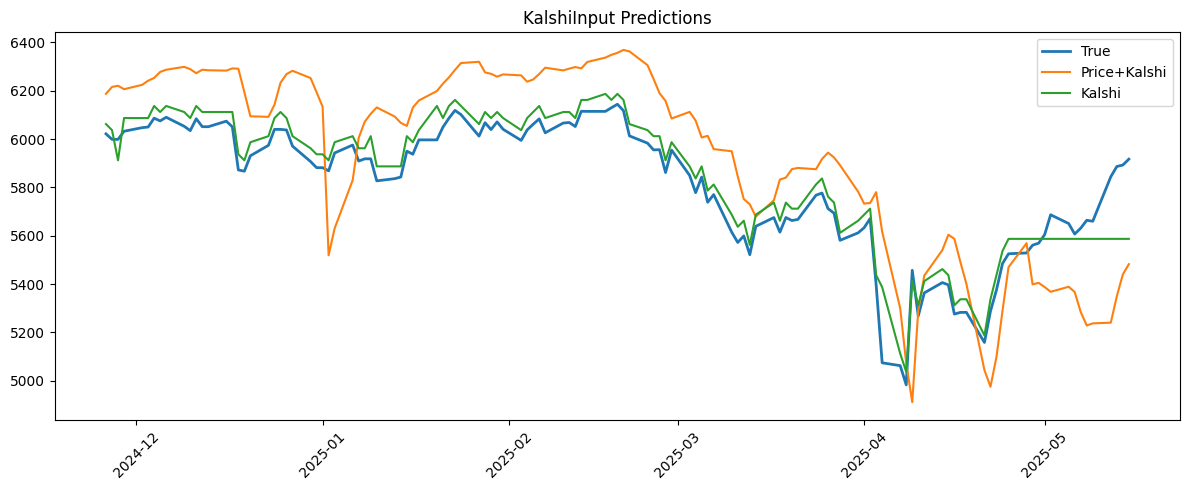

In [ ]:
MODEL_NAME = 'KalshiInput'

# 1) LOAD (use Kalshi as input feature, everything else off)
ds_pre_tr_kalshi, ds_pre_val_kalshi, \
ds_ft_kalshi,    ds_val_kalshi, \
Xp_test_kalshi,  Xs_test_kalshi, \
y_true_kalshi,   test_dates_kalshi, \
price_scaler_kalshi, kalshi_df_kalshi = get_datasets(
    cfg,
    use_sentiment=False,
    use_mag=False,
    use_tariff=False,
    use_kalshi=True
)

# 2) TRAIN price-only
price_model_kalshi = build_price()
price_model_kalshi.compile(Adam(cfg["lr_pre"]), loss="mse")
price_model_kalshi.fit(
    ds_pre_tr_kalshi, validation_data=ds_pre_val_kalshi,
    epochs=cfg["pre_epochs"], verbose=1
)

# 3) TRAIN price+Kalshi-input (fine-tune)
ft_model_kalshi = build_ft(Xs_test_kalshi.shape[2])
ft_model_kalshi.get_layer("ps") \
    .set_weights(price_model_kalshi.get_layer("ps").get_weights())
ft_model_kalshi.get_layer("ps").trainable = False
ft_model_kalshi.compile(Adam(cfg["lr_ft"]), loss="mse")
ft_model_kalshi.fit(
    ds_ft_kalshi, validation_data=ds_val_kalshi,
    epochs=cfg["ft_epochs"]//2, verbose=1
)
ft_model_kalshi.get_layer("ps").trainable = True
ft_model_kalshi.compile(Adam(cfg["lr_ft"]), loss="mse")
ft_model_kalshi.fit(
    ds_ft_kalshi, validation_data=ds_val_kalshi,
    epochs=cfg["ft_epochs"]//2, verbose=1
)

# 4) EVALUATE
y_ps_kalshi = np.exp(
    price_scaler_kalshi.inverse_transform(
        price_model_kalshi.predict(Xp_test_kalshi).reshape(-1,1)
    )
).flatten()

y_pa_kalshi = np.exp(
    price_scaler_kalshi.inverse_transform(
        ft_model_kalshi.predict([Xp_test_kalshi, Xs_test_kalshi]).reshape(-1,1)
    )
).flatten()

# compute MAEs for your models
mae_price_kalshi    = mean_absolute_error(y_true_kalshi, y_ps_kalshi)
mae_allinput_kalshi = mean_absolute_error(y_true_kalshi, y_pa_kalshi)
print("KalshiInput Price-only MAE:", mae_price_kalshi)
print("KalshiInput Price+Kalshi MAE:", mae_allinput_kalshi)

# ─── Kalshi baseline (aligned) ───────────────────────────────────────────────
if kalshi_df_kalshi is not None:
    kalshi_raw       = kalshi_df_kalshi["kalshi_price"]
    kalshi_aligned   = kalshi_raw.reindex(test_dates_kalshi, method="ffill")
    assert len(kalshi_aligned) == len(y_true_kalshi)
    mae_kalshi_base  = mean_absolute_error(y_true_kalshi, kalshi_aligned.values)
    print("KalshiInput Kalshi baseline MAE (aligned):", mae_kalshi_base)
else:
    mae_kalshi_base = np.nan

# 5) WRITE TO CSV
upsert_experiment(
    CSV_FILE,
    exp_name   = EXP_NAME,
    row_values = {
        'Price-only':  mae_price_kalshi,
        'Kalshi':      mae_kalshi_base,
        'KalshiInput': mae_allinput_kalshi
    },
    overwrite= True
)

# 6) PLOT & SAVE
fig_kalshi, ax_kalshi = plt.subplots(figsize=(12,5))
ax_kalshi.plot(test_dates_kalshi, y_true_kalshi,      label="True",        lw=2)
ax_kalshi.plot(test_dates_kalshi, y_pa_kalshi,        label="Price+Kalshi")
if kalshi_df_kalshi is not None:
    ax_kalshi.plot(test_dates_kalshi, kalshi_aligned,  label="Kalshi")
ax_kalshi.set_title(f"{MODEL_NAME} Predictions")
ax_kalshi.legend()
plt.xticks(rotation=45)
plt.tight_layout()

fig_kalshi.savefig(os.path.join(OUTPUT_DIR, f"{MODEL_NAME}.png"), bbox_inches='tight')
print(f"Saved plot to {os.path.join(OUTPUT_DIR, MODEL_NAME + '.png')}")

## All Sentiment Data (Exc. Kalshi)

In [6]:
MODEL_NAME = 'AllExcKalshi'

# 1) LOAD (all sentiment features, no Kalshi input)
(ds_pre_tr_all, ds_pre_val_all, \
ds_ft_all,    ds_val_all, \
Xp_test_all,  Xs_test_all, \
y_true_all,   test_dates_all, \
price_scaler_all, kalshi_df_all) = get_datasets(
    cfg,
    use_sentiment=True,
    use_mag=True,
    use_tariff=True,
    use_kalshi=False
)

# 2) TRAIN price-only
price_model_all = build_price()
price_model_all.compile(Adam(cfg["lr_pre"]), loss="mse")
steps_per_epoch = len(X_pre_tr) // cfg["batch_size"]
val_steps = len(X_pre_val) // cfg["batch_size"]

price_model_all.fit(
    ds_pre_tr_all,
    validation_data=ds_pre_val_all,
    epochs=cfg["pre_epochs"],
    steps_per_epoch=steps_per_epoch,
    validation_steps=val_steps, 
    verbose=2
)

# 3) TRAIN price+all-sentiment (fine-tune)
ft_model_all = build_ft(Xs_test_all.shape[2])
ft_model_all.get_layer("ps") \
    .set_weights(price_model_all.get_layer("ps").get_weights())
ft_model_all.get_layer("ps").trainable = False
ft_model_all.compile(Adam(cfg["lr_ft"]), loss="mse")
ft_model_all.fit(
    ds_ft_all,
    validation_data=ds_val_all,
    epochs=cfg["ft_epochs"]//2,
    verbose=1
)
ft_model_all.get_layer("ps").trainable = True
ft_model_all.compile(Adam(cfg["lr_ft"]), loss="mse")
ft_model_all.fit(
    ds_ft_all,
    validation_data=ds_val_all,
    epochs=cfg["ft_epochs"]//2,
    verbose=1
)

# 4) EVALUATE
y_ps_all = np.exp(
    price_scaler_all.inverse_transform(
        price_model_all.predict(Xp_test_all).reshape(-1,1)
    )
).flatten()

y_pa_all = np.exp(
    price_scaler_all.inverse_transform(
        ft_model_all.predict([Xp_test_all, Xs_test_all]).reshape(-1,1)
    )
).flatten()

# 5) COMPUTE MAEs
mae_price_all   = mean_absolute_error(y_true_all, y_ps_all)
mae_allsent_all = mean_absolute_error(y_true_all, y_pa_all)
print("AllExcKalshi Price-only MAE:", mae_price_all)
print("AllExcKalshi Price+Sent MAE:", mae_allsent_all)

# ─── Kalshi baseline (aligned) ───────────────────────────────────────────────
if kalshi_df_all is not None:
    kalshi_raw_all     = kalshi_df_all["kalshi_price"]
    kalshi_aligned_all = kalshi_raw_all.reindex(test_dates_all, method="ffill")
    assert len(kalshi_aligned_all) == len(y_true_all), \
        f"Length mismatch: {len(kalshi_aligned_all)} vs {len(y_true_all)}"
    mae_kalshi_all     = mean_absolute_error(y_true_all, kalshi_aligned_all.values)
    print("AllExcKalshi Kalshi baseline MAE (aligned):", mae_kalshi_all)
else:
    mae_kalshi_all = np.nan

# 6) WRITE RESULTS TO CSV
upsert_experiment(
    CSV_FILE,
    exp_name   = EXP_NAME,
    row_values = {
        'Price-only':    mae_price_all,
        'Kalshi':        mae_kalshi_all,
        'AllExcKalshi':  mae_allsent_all
    },
    overwrite= True
)

# 7) PLOT & SAVE FIGURE
fig_all, ax_all = plt.subplots(figsize=(12,5))
ax_all.plot(test_dates_all, y_true_all,           label="True",        lw=2)
ax_all.plot(test_dates_all, y_pa_all,             label="Price+Sent")
if kalshi_df_all is not None:
    ax_all.plot(test_dates_all, kalshi_aligned_all, label="Kalshi")
ax_all.set_title(f"{MODEL_NAME} Predictions")
ax_all.legend()
plt.xticks(rotation=45)
plt.tight_layout()

fig_all.savefig(os.path.join(OUTPUT_DIR, f"{MODEL_NAME}.png"), bbox_inches='tight')
print(f"Saved plot to {os.path.join(OUTPUT_DIR, MODEL_NAME + '.png')}")

→ get_datasets: start
→ get_datasets: loading SPY
  → load_spy()
   SPY post-train shape: (1251, 1)
→ joining raw sentiment
  → load_sentiment()
→ joining raw Mag-7 sentiment
  → load_mag()
→ joining raw Mag-7 sentiment
  → load_mag()
→ joining raw Tariff sentiment
  → load_tariff()
→ joining raw Tariff sentiment
  → load_tariff()
→ get_datasets: loading raw Kalshi for baseline
  → load_kalshi() (optimized)
→ get_datasets: loading raw Kalshi for baseline
  → load_kalshi() (optimized)
→ scaling features
→ scaling features
→ making sequences
→ making sequences
→ splitting pretrain/fine-tune
→ creating tf.data datasets
→ splitting pretrain/fine-tune
→ creating tf.data datasets
→ preparing test data
→ get_datasets: done
→ preparing test data
→ get_datasets: done


NameError: name 'X_pre_tr' is not defined

## All Sentiment (Inc. Kalshi)

In [ ]:
MODEL_NAME = 'All'

# 1) LOAD (all features including Kalshi)
(ds_pre_tr_all, ds_pre_val_all, \
ds_ft_all,    ds_val_all, \
Xp_test_all,  Xs_test_all, \
y_true_all,   test_dates_all, \
price_scaler_all, kalshi_df_all) = get_datasets(
    cfg,
    use_sentiment=True,
    use_mag=True,
    use_tariff=True,
    use_kalshi=True
)

# 2) TRAIN price-only
price_model_all = build_price()
price_model_all.compile(Adam(cfg["lr_pre"]), loss="mse")
price_model_all.fit(
    ds_pre_tr_all, validation_data=ds_pre_val_all,
    epochs=cfg["pre_epochs"], verbose=1
)

# 3) TRAIN price+all-inputs (fine-tune)
ft_model_all = build_ft(Xs_test_all.shape[2])
ft_model_all.get_layer("ps") \
    .set_weights(price_model_all.get_layer("ps").get_weights())
ft_model_all.get_layer("ps").trainable = False
ft_model_all.compile(Adam(cfg["lr_ft"]), loss="mse")

steps_per_epoch_ft = len(Xp_tr) // cfg["batch_size"]
val_steps_ft = len(Xp_val) // cfg["batch_size"]

ft_model_all.fit(
    ds_ft_all, validation_data=ds_val_all,
    epochs=cfg["ft_epochs"]//2,
    steps_per_epoch=steps_per_epoch_ft,
    validation_steps=val_steps_ft,
    verbose=1
)
ft_model_all.get_layer("ps").trainable = True
ft_model_all.compile(Adam(cfg["lr_ft"]), loss="mse")

ft_model_all.fit(
    ds_ft_all, validation_data=ds_val_all,
    epochs=cfg["ft_epochs"]//2,
    steps_per_epoch=steps_per_epoch_ft,
    validation_steps=val_steps_ft, 
    verbose=1
)

# 4) EVALUATE
y_ps_all = np.exp(
    price_scaler_all.inverse_transform(
        price_model_all.predict(Xp_test_all).reshape(-1,1)
    )
).flatten()
y_pa_all = np.exp(
    price_scaler_all.inverse_transform(
        ft_model_all.predict([Xp_test_all, Xs_test_all]).reshape(-1,1)
    )
).flatten()

# 5) COMPUTE MAEs
mae_price_all     = mean_absolute_error(y_true_all, y_ps_all)
mae_allinputs_all = mean_absolute_error(y_true_all, y_pa_all)
print("All Price-only MAE:", mae_price_all)
print("All Price+AllInputs MAE:", mae_allinputs_all)

# ─── Kalshi baseline (aligned) ───────────────────────────────────────────────
if kalshi_df_all is not None:
    kalshi_raw_all     = kalshi_df_all["kalshi_price"]
    # reindex to your test dates and forward-fill
    kalshi_aligned_all = kalshi_raw_all.reindex(test_dates_all, method="ffill")
    assert len(kalshi_aligned_all) == len(y_true_all), \
        f"Length mismatch: {len(kalshi_aligned_all)} vs {len(y_true_all)}"
    mae_kalshi_all     = mean_absolute_error(y_true_all, kalshi_aligned_all.values)
    print("All Kalshi baseline MAE (aligned):", mae_kalshi_all)
else:
    mae_kalshi_all = np.nan

# 6) WRITE TO CSV (rows=Price-only, Kalshi, All; column=EXP_NAME)
upsert_experiment(
    CSV_FILE,
    exp_name   = EXP_NAME,
    row_values = {
        'Price-only': mae_price_all,
        'Kalshi':     mae_kalshi_all,
        'All':        mae_allinputs_all
    },
    overwrite= True
)

# 7) PLOT & SAVE
fig_all, ax_all = plt.subplots(figsize=(12,5))
ax_all.plot(test_dates_all, y_true_all,           label="True",        lw=2)
ax_all.plot(test_dates_all, y_pa_all,             label="Price+AllInputs")
if kalshi_df_all is not None:
    ax_all.plot(test_dates_all, kalshi_aligned_all, label="Kalshi")
ax_all.set_title(f"{MODEL_NAME} Predictions")
ax_all.legend()
plt.xticks(rotation=45)
plt.tight_layout()

fig_all.savefig(os.path.join(OUTPUT_DIR, f"{MODEL_NAME}.png"), bbox_inches='tight')
print(f"Saved plot to {os.path.join(OUTPUT_DIR, MODEL_NAME + '.png')}")

→ get_datasets: start
→ get_datasets: loading SPY
  → load_spy()
   SPY post-train shape: (1251, 1)
→ joining raw sentiment
  → load_sentiment()
→ joining raw Mag-7 sentiment
  → load_mag()
→ joining raw Tariff sentiment
  → load_tariff()
→ get_datasets: loading raw Kalshi for baseline
  → load_kalshi() (optimized)
→ get_datasets: joining Kalshi as input feature
→ scaling features
→ making sequences
→ splitting pretrain/fine-tune
→ creating tf.data datasets
→ preparing test data
→ get_datasets: done


NameError: name 'kalshi' is not defined

## Plotting

Best Price+Sent model: Mag7 (MAE=138.1164)


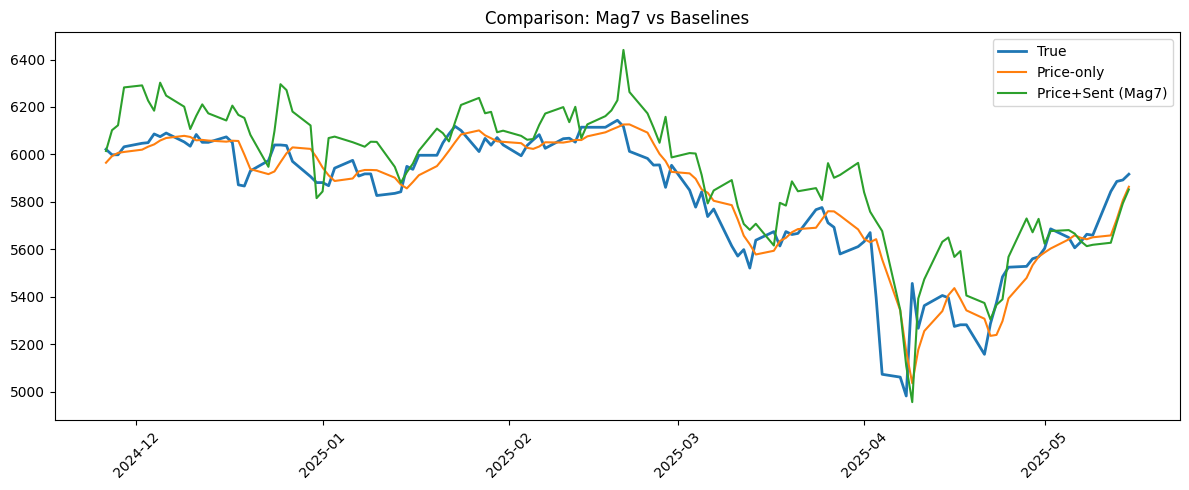

In [ ]:
# 1) Gather your Price+Sent MAEs
mae_price_sent = {
    'SPY':           mae_sent_spy,
    'Mag7':          mae_allsent_mag7,
    'Tariffs':       mae_sent_tariffs,
    'KalshiInput':   mae_allinput_kalshi,
    'AllExcKalshi':  mae_allsent_all,
    'All':           mae_allinputs_all
}

# 2) Pick the best model
best_model = min(mae_price_sent, key=mae_price_sent.get)
print(f"Best Price+Sent model: {best_model} (MAE={mae_price_sent[best_model]:.4f})")

# 3) Wire up the corresponding variables
if best_model == 'SPY':
    dates = test_dates_spy
    true  = y_true_spy
    price = y_ps_spy
    sent  = y_p_spy
    kalshi = pd.Series(
        kalshi_raw.values,
        index=kalshi_raw.index
    ) if 'kalshi_raw' in locals() else None

elif best_model == 'Mag7':
    dates = test_dates_mag7
    true  = y_true_mag7
    price = y_ps_mag7
    sent  = y_pa_mag7
    kalshi = pd.Series(
        kts_mag7,
        index=test_dates_mag7[:len(kts_mag7)]
    ) if 'kts_mag7' in locals() else None

elif best_model == 'Tariffs':
    dates = test_dates_tariffs
    true  = y_true_tariffs
    price = y_ps_tariffs
    sent  = y_pa_tariffs
    kalshi = pd.Series(
        kts_tariffs,
        index=test_dates_tariffs[:len(kts_tariffs)]
    ) if 'kts_tariffs' in locals() else None

elif best_model == 'KalshiInput':
    dates = test_dates_kalshi
    true  = y_true_kalshi
    price = y_ps_kalshi
    sent  = y_pa_kalshi
    kalshi = pd.Series(
        kts_kalshi,
        index=test_dates_kalshi[:len(kts_kalshi)]
    ) if 'kts_kalshi' in locals() else None

elif best_model == 'AllExcKalshi':
    dates = test_dates_all
    true  = y_true_all
    price = y_ps_all
    sent  = y_pa_all
    # no Kalshi input in this block
    kalshi = None

else:  # 'All'
    dates = test_dates_all
    true  = y_true_all
    price = y_ps_all
    sent  = y_pa_all
    kalshi = pd.Series(
        kts_all,
        index=test_dates_all[:len(kts_all)]
    ) if 'kts_all' in locals() else None

# 4) Plot everything
fig, ax = plt.subplots(figsize=(12,5))
ax.plot(dates, true,  label='True',        lw=2)
ax.plot(dates, price, label='Price-only')
ax.plot(dates, sent,  label=f'Price+Sent ({best_model})')

if kalshi is not None:
    ax.plot(kalshi.index, kalshi.values, label='Kalshi')

ax.set_title(f'Comparison: {best_model} vs Baselines')
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
